In [4]:
import pandas as pd

orders_df = pd.read_csv("orders.csv", encoding='latin1')
details_df = pd.read_csv("order_details.csv", encoding='latin1')
pizzas_df = pd.read_csv("pizzas.csv", encoding='latin1')
types_df = pd.read_csv("pizza_types.csv", encoding='latin1')

orders_df.head() 

,order_id,date,time
0,1,01-01-2015,11:38:36
1,2,01-01-2015,11:57:40
2,3,01-01-2015,12:12:28
3,4,01-01-2015,12:16:31
4,5,01-01-2015,12:21:30


In [5]:
# 1. Pehle details aur orders table ko 'order_id' ke jariye jodein
master_df = pd.merge(details_df, orders_df, on="order_id", how="inner")

# 2. Phir usme pizzas table ko 'pizza_id' ke jariye jodein
master_df = pd.merge(master_df, pizzas_df, on="pizza_id", how="inner")

# 3. Akhir mein pizza_types table ko 'pizza_type_id' ke jariye jodein
final_df = pd.merge(master_df, types_df, on="pizza_type_id", how="inner")

# Final master table ki pehli 5 rows check karein
final_df.head() 

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,01-01-2015,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [6]:
!pip install prophet

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 325.1 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 372.4 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 271.3 kB/s eta 0:00:00
     ---------------------------------------- 0.0/53.0 kB ? eta -:--:--
     ---------------------------------------- 53.0/53.0 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/121.0 kB ? eta -:--:--
     ----------------------------------- -- 112.6/121.0 kB 2.2 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 1.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -----------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Date column ko badlein (errors='coerce' lagaya hai taaki kharab dates se code na ruke)
final_df['date_clean'] = pd.to_datetime(final_df['date'], errors='coerce')

# 2. Agar koi date kharab thi toh us poori row ko hata dein (Data Cleaning)
final_df = final_df.dropna(subset=['date_clean'])

# 3. Revenue (Total Sales) nikalna
final_df['revenue'] = final_df['quantity'] * final_df['price']

# 4. Date wise daily revenue ko group (total) karein
daily_sales = final_df.groupby('date_clean')['revenue'].sum().reset_index()

# 5. Prophet ke hisab se columns ka naam 'ds' aur 'y' rakhein
daily_sales.columns = ['ds', 'y']

# Check karein ki table bani ya nahi
daily_sales.head() 

,ds,y
0,2015-01-01,2713.85
1,2015-01-02,3189.20
2,2015-01-03,1598.55
3,2015-01-04,2176.85
4,2015-01-05,2571.95


14:11:00 - cmdstanpy - INFO - Chain [1] start processing
14:11:01 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\India\AppData\Local\Temp\ipykernel_960\598649775.py:19: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) DejaVu Sans.
  plt.savefig("pizza_sales_forecast.png")


<Figure size 1000x600 with 0 Axes>

C:\Users\India\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


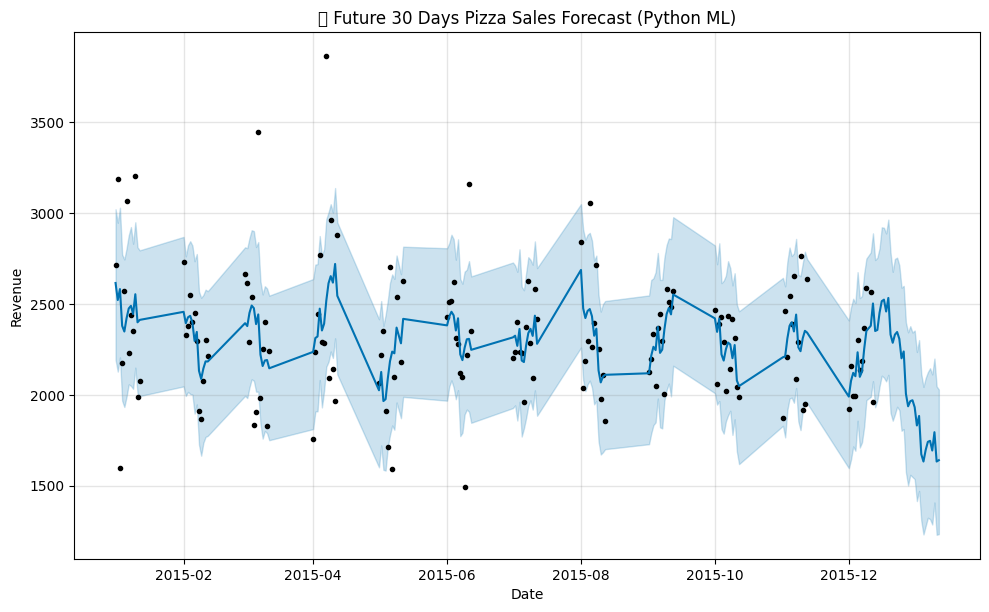

In [10]:
# 1. Model ko banna aur train karna
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(daily_sales)

# 2. Agle 30 dino ki future dates (calendar) banana
future = model.make_future_dataframe(periods=30)

# 3. Future ki sales predict karna
forecast = model.predict(future)

# 4. Prediction ka shaandar graph plot karna
plt.figure(figsize=(10, 6))
model.plot(forecast)
plt.title("🍕 Future 30 Days Pizza Sales Forecast (Python ML)")
plt.xlabel("Date")
plt.ylabel("Revenue")

# Is graph ko laptop mein save karlein takki GitHub/PPT mein laga sakein
plt.savefig("pizza_sales_forecast.png")
plt.show() 